# Data Loading & Date Parsing

## Imports

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Load Data

In [85]:
df = pd.read_csv("../data/sudan.csv")  # replace with your file
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


## Add Country Column

In [86]:
df["Country"] = "Sudan"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


## Convert the YEAR and DOY columns into datetime column

In [87]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.drop(columns=["YEAR", "DOY"], inplace=True)
df.rename(columns={"date": "YEAR"}, inplace=True)
df.tail()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR
4103,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27
4104,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28
4105,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29
4106,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30
4107,33.79,42.64,25.73,16.91,0.0,13.89,3.52,5.00,95.89,4.47,Sudan,2026-03-31


## Extract Month

In [88]:
df["month"] = df["YEAR"].dt.month
df.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR,month
0,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


# Summary Statistics & Missing-Value Report

## Replace all occurrences of -999 with np.nan

In [89]:
df = df.replace(-999, np.nan)

## drop any duplicate rows

In [90]:
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

Number of duplicate rows: 0
Empty DataFrame
Columns: [T2M, T2M_MAX, T2M_MIN, T2M_RANGE, PRECTOTCORR, RH2M, WS2M, WS2M_MAX, PS, QV2M, Country, YEAR, month]
Index: []


In [91]:
df.describe(include="number")

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,6.423564
std,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,3.477046
min,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,1.000000
25%,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,3.000000
50%,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,6.000000
75%,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,9.000000
max,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,12.000000


## Summary Statistics Interpretation

The dataset reflects a **hot and predominantly dry climate** with high temperatures, low average rainfall, and substantial variability in humidity.

- **Mean temperature (~28.8°C)** indicates consistently hot conditions, with moderate variability across the year.
- **Daily temperature range (~15.3°C)** is relatively large, suggesting strong day–night temperature contrasts typical of drier climates.
- **Precipitation is strongly right-skewed**, with many days receiving little or no rainfall (median ≈ 0), punctuated by occasional intense rainfall events (up to 66 mm/day).
- **Relative humidity averages ~31%**, indicating generally dry atmospheric conditions, though variability suggests some seasonal moisture influence.
- **Wind speeds are moderate** and fairly consistent, while **surface pressure is highly stable**, suggesting limited atmospheric pressure fluctuation.
- **Specific humidity shows substantial spread**, indicating strong variation in moisture content despite overall dry conditions.

Overall, the dataset appears characteristic of an **arid to semi-arid climate**, where **temperature and moisture variability**, rather than frequent rainfall, are the dominant climatic features.

## missing values per column

In [92]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
YEAR           0
month          0
dtype: int64

In [93]:
missing_percent = (df.isna().sum() / len(df)) * 100
high_missing = missing_percent[missing_percent > 5]
high_missing

Series([], dtype: float64)

Interpretation of Missing Data (>5%)

Columns with **more than 5% missing values** may indicate issues in **data collection, sensor failure, or incomplete records**.

Key implications:
- Missing **precipitation data** could bias rainfall analysis and lead to incorrect conclusions about wet and dry seasons.
- Missing **temperature values** may distort seasonal trends and affect climate pattern interpretation.
- Missing **humidity or wind data** can reduce the reliability of atmospheric condition analysis.

Recommended handling:
- **Imputation** (mean, median, interpolation) for moderate missingness
- **Removal** if the column is not critical or has excessive missing data
- **Careful evaluation** before deciding, based on the importance of the variable in analysis or modeling

Overall, columns with high missingness should be treated carefully to avoid introducing bias into the analysis.

# Outlier Detection & Basic Cleaning

## Compute Z-scores

In [94]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
# Compute Z-scores
z_scores = df[cols].apply(stats.zscore)
z_scores

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-0.764625,-0.278192,-1.054609,-0.210603,0.028617,-0.023308,-0.029200
1,-1.033813,-0.598681,-1.119435,-0.210603,-0.421811,0.726303,-0.044824
2,-1.288047,-1.166924,-1.260875,-0.210603,0.383806,1.466303,0.845744
3,-2.052884,-2.142028,-1.695015,-0.210603,-0.576436,2.148641,1.408208
4,-2.396847,-2.171577,-2.360958,-0.210603,-0.547864,0.764745,0.517640
...,...,...,...,...,...,...,...
4103,-0.185656,-0.473668,0.031724,-0.210603,-0.946190,0.168900,-0.037012
4104,-0.006197,-0.037257,-0.033103,-0.210603,-1.210621,-0.263568,-0.591664
4105,0.277946,0.480980,-0.070427,-0.210603,-1.105297,-1.032399,-1.005700
4106,0.799232,1.081044,0.412824,-0.210603,-0.969160,-0.647983,-0.224500


### Flag rows where |Z| > 3

In [95]:
# Flag rows where |Z| > 3 in ANY column
outlier_mask = (z_scores.abs() > 3).any(axis=1)
outlier_rows = df[outlier_mask]

# outlier_rows.to_csv("../data/outliers.csv", index=False)

### Count how many rows contain at least one outlier

In [96]:
outlier_counts = (z_scores.abs() > 3).sum()
outlier_counts

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64

In [97]:
# Summary report
print("*** Z-Score Outlier Report ***\n")
print("Outliers per column:")
print(outlier_counts.to_string())
print(f"\nTotal rows flagged (outlier in ANY column): {outlier_mask.sum()}")
print(f"Percentage of dataset flagged: {outlier_mask.sum() / len(df) * 100:.2f}%")
print(f"\nFlagged rows preview:")
print(outlier_rows[cols].head(10))

*** Z-Score Outlier Report ***

Outliers per column:
T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3

Total rows flagged (outlier in ANY column): 84
Percentage of dataset flagged: 2.04%

Flagged rows preview:
       T2M  T2M_MAX  T2M_MIN  PRECTOTCORR   RH2M  WS2M  WS2M_MAX
8    14.29    22.39     7.83         0.00  23.46  5.58      7.90
9    13.18    21.04     6.59         0.00  32.34  5.03      7.66
10   14.21    23.32     5.93         0.00  30.62  4.36      6.15
223  32.64    41.23    25.96        23.61  48.05  4.65      8.41
392  14.76    23.33     7.42         0.00  24.26  4.49      6.86
557  26.18    27.99    24.55        66.49  83.08  3.47      5.05
562  27.92    32.54    24.34        11.63  69.86  4.20      5.50
575  27.45    31.67    24.36        12.02  70.47  4.67      6.43
585  28.97    37.66    23.51        10.09  61.51  3.73      4.81
586  25.51    30.76    22.93        44.96  79.25  4.20      5.2

### Outlier Handling Decision (Integrated Analysis)

The outlier analysis shows that **84 rows (2.04%)** of the dataset are flagged as containing at least one outlier. This is a **very small proportion** of the full dataset, suggesting the flagged observations are more likely **natural extremes** than data quality problems or sensor errors.

#### 1. Nature of Outliers by Variable

- **PRECTOTCORR (71 outliers)**  
  Most outliers occur in precipitation. Given the earlier distribution analysis (strong right-skew, near-zero median rainfall, and maximum of 66.49 mm/day), these are consistent with **episodic heavy rainfall events**, not erroneous values.

- **Temperature variables (T2M, T2M_MAX, T2M_MIN)**  
  Very few outliers are detected:
  - T2M: 3  
  - T2M_MAX: 6  
  - T2M_MIN: 1  

  These likely represent **rare but plausible extreme heat or cool conditions**, not anomalies.

- **RH2M (3 outliers)**  
  Very few humidity outliers occur, suggesting humidity is largely stable despite a broad range (4.69%–87.16%). These likely reflect **rare dry or moist atmospheric episodes**.

- **Wind variables (WS2M, WS2M_MAX)**  
  Only a handful of outliers (4 and 3) indicate generally stable wind conditions, with occasional stronger wind events.

#### 2. Contextual Interpretation

- The dataset reflects a **hot, dry-to-semi-arid climate**, with variability driven more by **rainfall extremes** than by temperature anomalies.
- Precipitation outliers align with **short-lived intense storm events**, which are meaningful climate signals rather than noise.
- Temperature and humidity outliers are sparse and fall within physically plausible ranges.
- Previewed flagged rows show combinations of:
  - intense rainfall + high humidity  
  - unusually cool days + strong winds  

  These patterns suggest **real meteorological events**, not random errors.

Removing these values would reduce the dataset’s ability to represent **climate variability and extremes**, particularly rare rainfall events.

#### 3. Decision

- **Outliers not to be removed globally.**

- Instead:
  - Retain all observations for **climate and seasonal analysis**
  - Apply **log transformation** (e.g., `log1p`) for PRECTOTCORR in modeling or skew-sensitive analysis


#### ✅ Conclusion

The detected outliers appear to represent **valid extreme weather observations rather than data errors**. They should be retained to preserve the realism of rainfall variability, rare weather events, and overall climate behavior.

## Handle remaining missing values

In [98]:
# Step 1: Define threshold (30% missing)
threshold = int(df.shape[1] * 0.3)

# Step 2: Drop rows with too many missing values
df_cleaned = df[df.isnull().sum(axis=1) <= threshold]
print(df_cleaned)
# Step 3: Forward-fill remaining missing values
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX","YEAR"]

df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")


        T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  WS2M_MAX  \
0     25.18    35.55    16.14      19.41          0.0  31.87  3.46      5.12   
1     23.92    34.14    15.81      18.33          0.0  23.83  4.24      5.10   
2     22.73    31.64    15.09      16.55          0.0  38.21  5.01      6.24   
3     19.15    27.35    12.88      14.47          0.0  21.07  5.72      6.96   
4     17.54    27.22     9.49      17.73          0.0  21.58  4.28      5.82   
...     ...      ...      ...        ...          ...    ...   ...       ...   
4103  27.89    34.69    21.67      13.02          0.0  14.47  3.66      5.11   
4104  28.73    36.61    21.34      15.27          0.0   9.75  3.21      4.40   
4105  30.06    38.89    21.15      17.74          0.0  11.63  2.41      3.87   
4106  32.50    41.53    23.61      17.92          0.0  14.06  2.81      4.87   
4107  33.79    42.64    25.73      16.91          0.0  13.89  3.52      5.00   

         PS  QV2M Country       YEAR  m

C:\Users\bemnet\AppData\Local\Temp\ipykernel_20788\579216781.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")


## Export the cleaned DataFrame

In [99]:
df_cleaned[weather_cols].to_csv("../data/sudan_clean.csv", index=False)

# Time Series Analysis

In [100]:
df["date"] = pd.to_datetime(df["YEAR"])
# Create Year-Month column
df["year_month"] = df["date"].dt.to_period("M")
# Compute monthly average T2M
monthly_avg = df.groupby("year_month")["T2M"].mean().reset_index()
# Convert back to timestamp for plotting
monthly_avg["year_month"] = monthly_avg["year_month"].dt.to_timestamp()
# Find warmest and coolest months
warmest = monthly_avg.loc[monthly_avg["T2M"].idxmax()]
coolest = monthly_avg.loc[monthly_avg["T2M"].idxmin()]


##  monthly average T2M

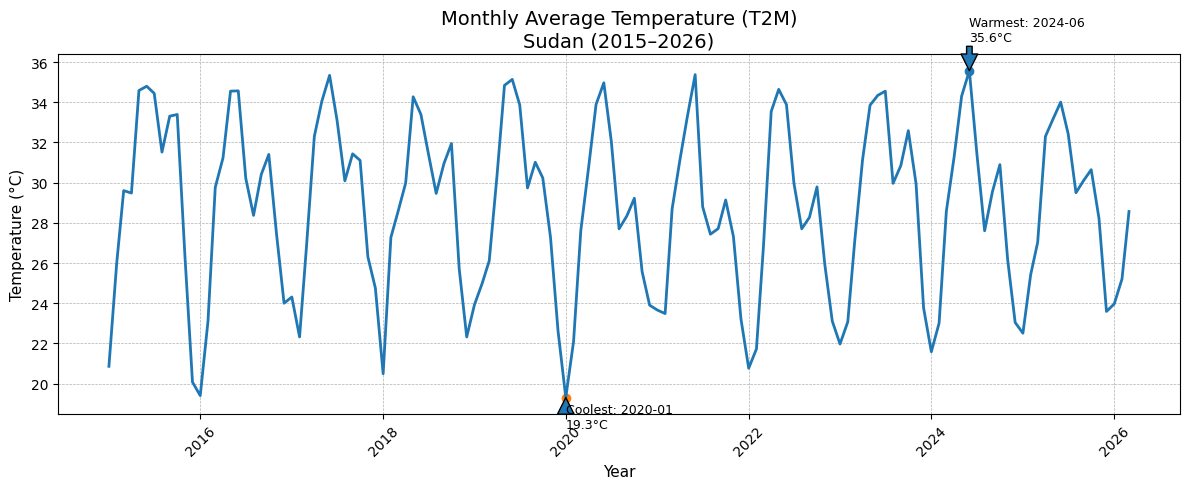

In [101]:

plt.figure(figsize=(12, 5))  # wider for time series

# Line plot
plt.plot(monthly_avg["year_month"], monthly_avg["T2M"], linewidth=2)

# Highlight warmest & coolest points
plt.scatter(warmest["year_month"], warmest["T2M"])
plt.scatter(coolest["year_month"], coolest["T2M"])

# Annotate warmest
plt.annotate(
    f"Warmest: {warmest['year_month'].strftime('%Y-%m')}\n{warmest['T2M']:.1f}°C",
    xy=(warmest["year_month"], warmest["T2M"]),
    xytext=(warmest["year_month"], warmest["T2M"] + 1.5),
    arrowprops=dict(),
    fontsize=9
)

# Annotate coolest
plt.annotate(
    f"Coolest: {coolest['year_month'].strftime('%Y-%m')}\n{coolest['T2M']:.1f}°C",
    xy=(coolest["year_month"], coolest["T2M"]),
    xytext=(coolest["year_month"], coolest["T2M"] - 1.5),
    arrowprops=dict(),
    fontsize=9
)

# Titles and labels
plt.title("Monthly Average Temperature (T2M)\nSudan (2015–2026)", fontsize=14)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Temperature (°C)", fontsize=11)

# Grid for readability
plt.grid(True, linestyle="--", linewidth=0.5)

# Improve x-axis ticks (less crowded)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## monthly total PRECTOTCORR

In [102]:
monthly_rain = df.groupby("year_month")["PRECTOTCORR"].sum().reset_index()

monthly_rain["year_month"] = monthly_rain["year_month"].dt.to_timestamp()
peak_months = monthly_rain.nlargest(2, "PRECTOTCORR")

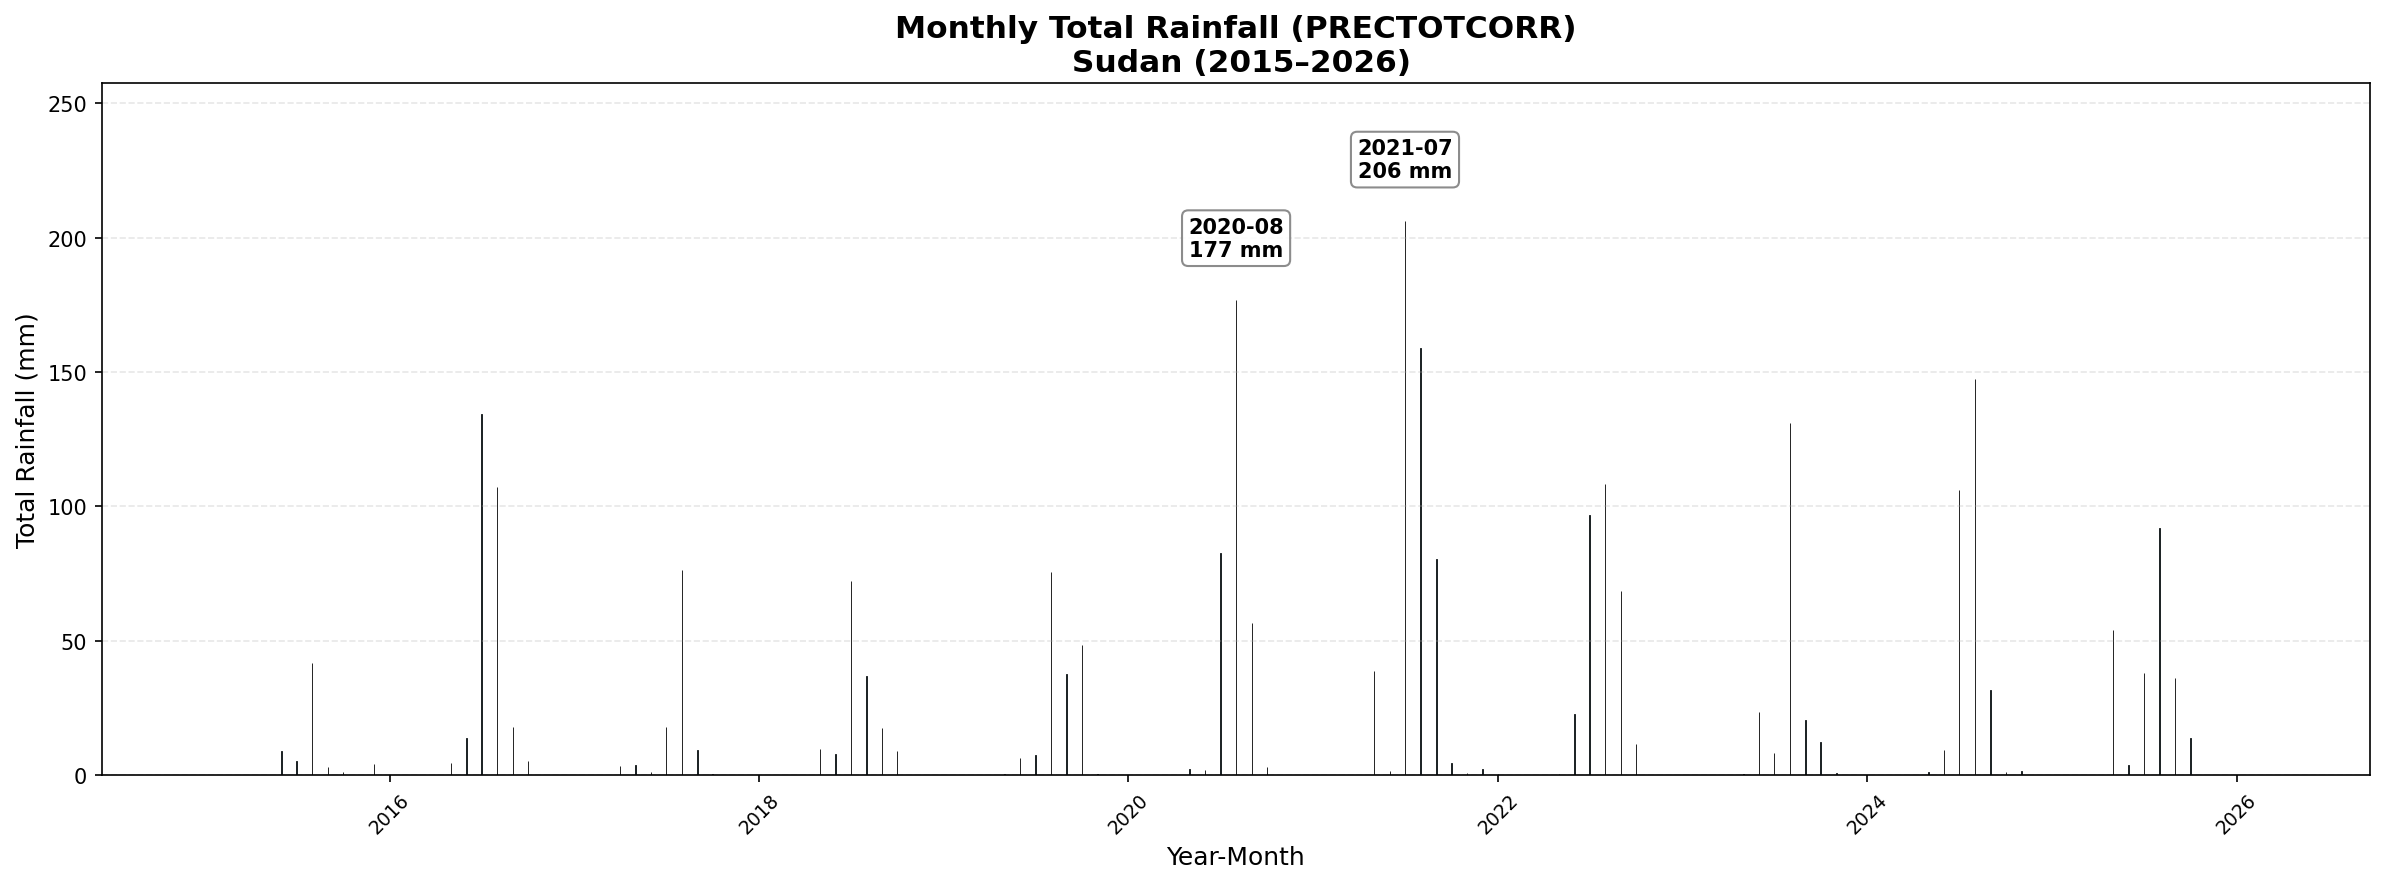

In [103]:
plt.figure(figsize=(16, 6), dpi=150)

monthly_rain_sorted = monthly_rain.sort_values("year_month")

# Base bar plot
plt.bar(
    monthly_rain_sorted["year_month"],
    monthly_rain_sorted["PRECTOTCORR"],
    color="skyblue",
    edgecolor="black",
    linewidth=0.4
)

# Peak months
peak_months = monthly_rain_sorted.nlargest(2, "PRECTOTCORR")

# Dynamic y-limit padding (IMPORTANT FIX)
y_max = monthly_rain_sorted["PRECTOTCORR"].max()
plt.ylim(0, y_max * 1.25)

# Place annotations HIGH ABOVE bars (fixed position logic)
for _, row in peak_months.iterrows():
    plt.text(
        row["year_month"],
        row["PRECTOTCORR"] + (y_max * 0.08),  # always above bar
        f"{row['year_month'].strftime('%Y-%m')}\n{row['PRECTOTCORR']:.0f} mm",
        ha="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    )

# Styling
plt.title("Monthly Total Rainfall (PRECTOTCORR)\n Sudan (2015–2026)",
          fontsize=15, fontweight="bold")

plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Total Rainfall (mm)", fontsize=12)

plt.xticks(rotation=45, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation & Relationship Analysis

## Heatmap of correlations

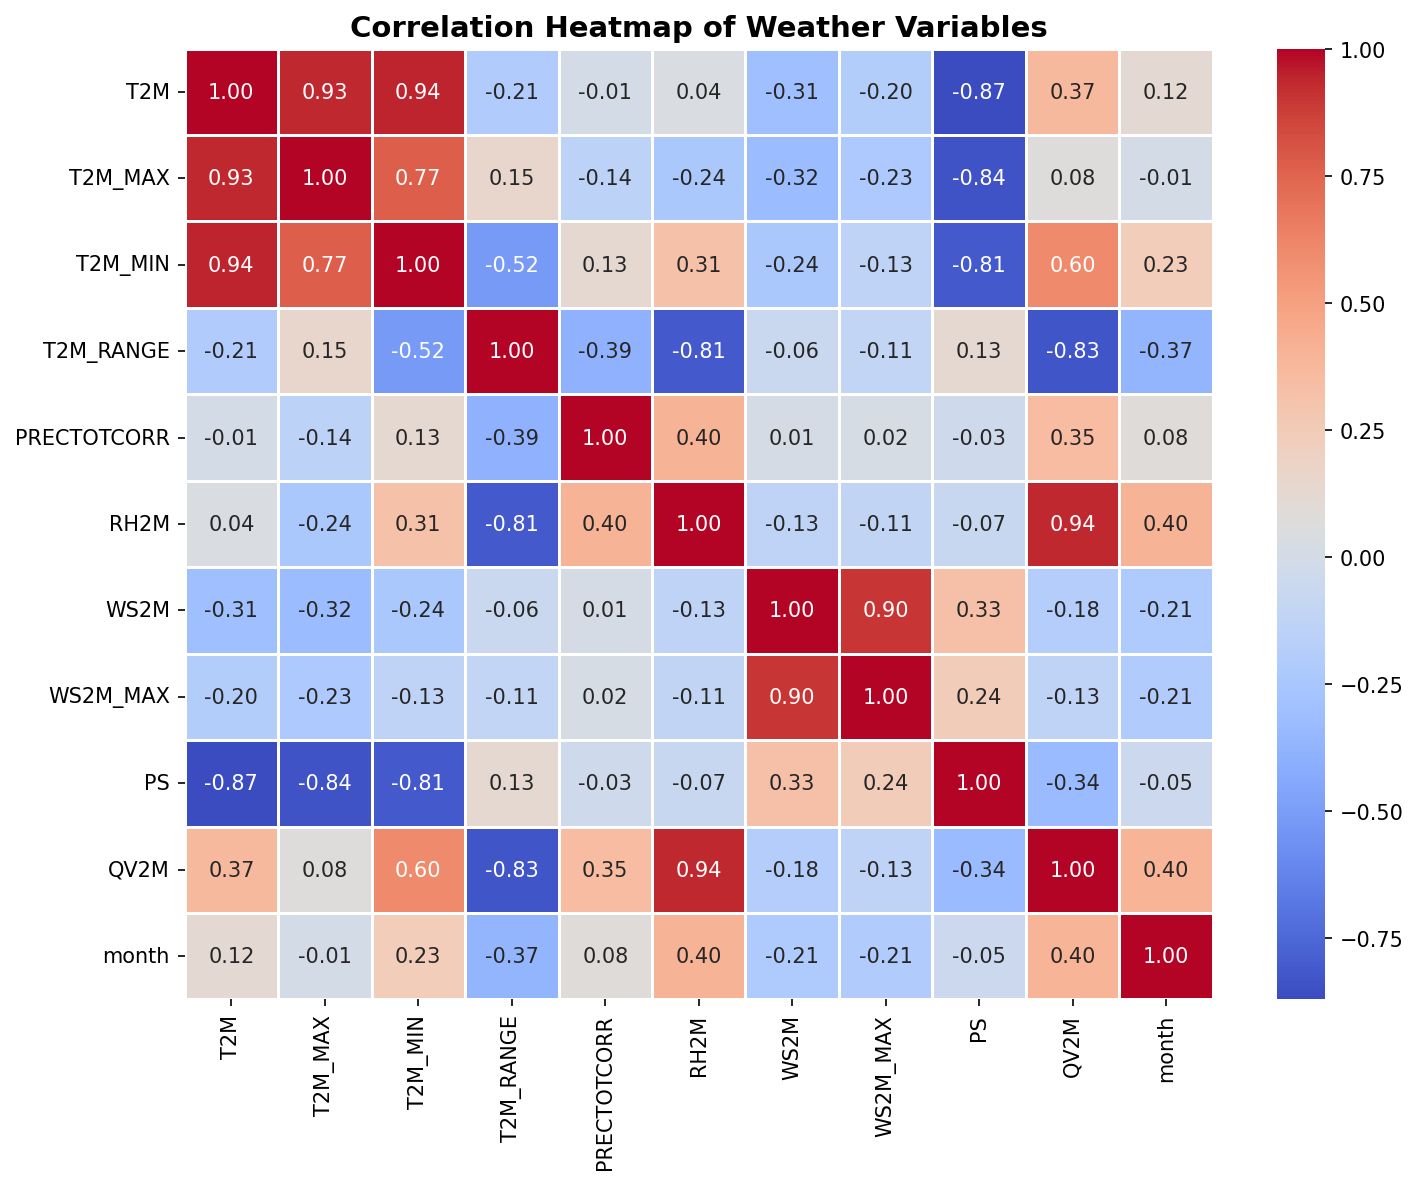

In [104]:
# Select only numeric columns and compute correlation matrix
# This measures how strongly each variable is linearly related to others
corr = df.select_dtypes(include="number").corr()
# Set figure size and resolution for better readability
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap of correlation matrix
sns.heatmap(
    corr,              # correlation values
    annot=True,        # show numerical values inside cells
    fmt=".2f",         # format numbers to 2 decimal places
    cmap="coolwarm",   # color scheme (blue = negative, red = positive)
    linewidths=0.5     # adds spacing between cells for clarity
)

# Add title to the plot
plt.title("Correlation Heatmap of Weather Variables", fontsize=14, fontweight="bold")

# Improve layout so labels don’t overlap
plt.tight_layout()

# Display the plot
plt.show()

## T2M vs RH2M (Temperature vs Humidity)

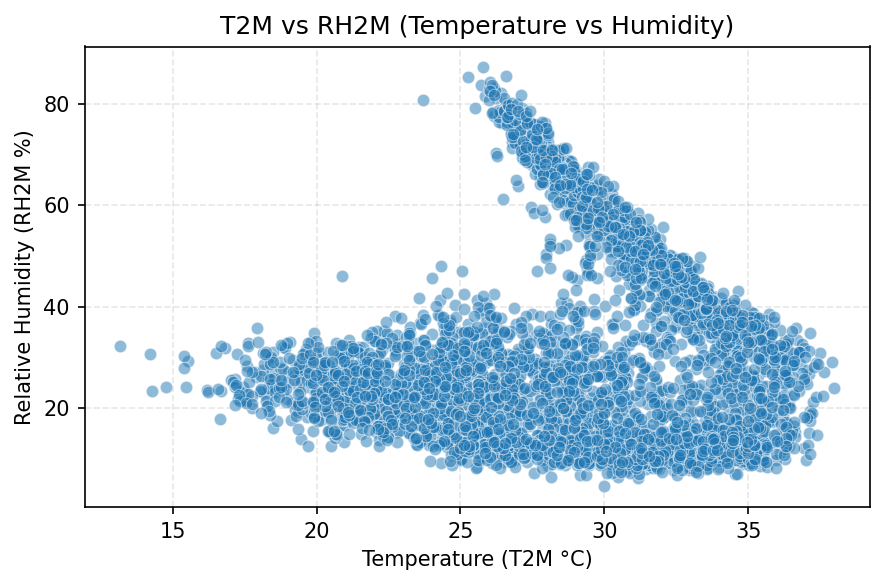

In [105]:
plt.figure(figsize=(6,4), dpi=150)

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    alpha=0.5
)

plt.title("T2M vs RH2M (Temperature vs Humidity)")
plt.xlabel("Temperature (T2M °C)")
plt.ylabel("Relative Humidity (RH2M %)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## T2M_RANGE vs WS2M (Temperature Range vs Wind Speed)

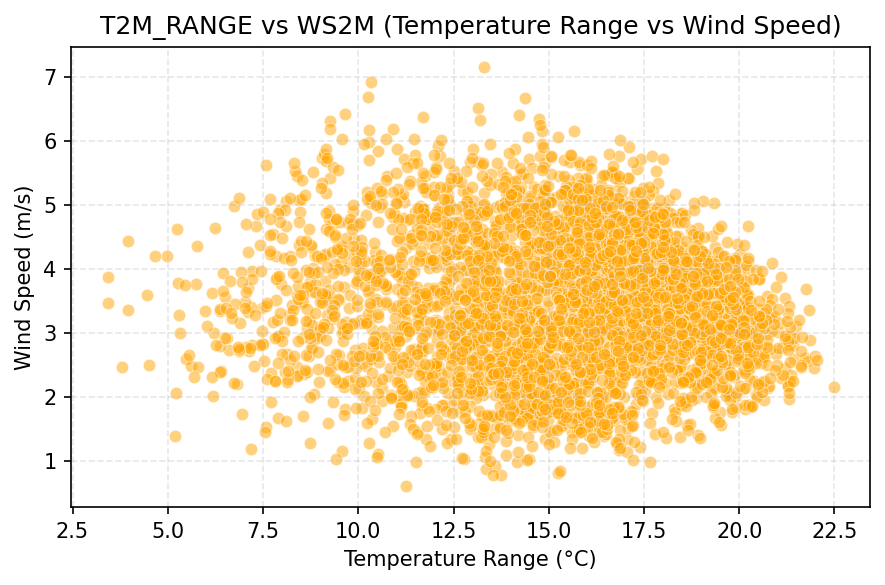

In [106]:
plt.figure(figsize=(6,4), dpi=150)

sns.scatterplot(
    data=df,
    x="T2M_RANGE",
    y="WS2M",
    alpha=0.5,
    color="orange"
)

plt.title("T2M_RANGE vs WS2M (Temperature Range vs Wind Speed)")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Scatter Plot Insights

- **T2M vs RH2M:**  
  A pronounced **negative relationship** is visible — as temperature increases, relative humidity generally decreases.  
  The plot shows a dense cluster of low-humidity observations (roughly 10–35%) at higher temperatures, while higher humidity values occur mostly at moderate temperatures.  
  There also appears to be a **nonlinear triangular structure**, suggesting humidity variability narrows as temperature increases.  
  → This indicates strong **temperature–moisture coupling**, where warmer conditions are generally associated with drier atmospheric conditions.

- **T2M_RANGE vs WS2M:**  
  The relationship between daily temperature range and wind speed appears **weak to slightly negative**, with substantial dispersion.  
  Most observations cluster around moderate wind speeds (2–5 m/s) across a wide range of temperature ranges, and no strong linear trend is evident.  
  Some higher wind speeds occur at lower-to-mid temperature ranges, but large temperature ranges are mostly associated with moderate winds.  
  → Wind speed appears to have **limited direct control** over daily temperature range, though it may contribute modestly to variability.

### Overall Insight
> The climate dynamics appear strongly influenced by **temperature–humidity interactions**, with warmer conditions linked to lower humidity, while **wind shows comparatively little explanatory power** for temperature-range variability. Moisture variability seems much more structured than wind-driven variability.

## Distribution Analysis

### Histogram of PRECTOTCORR

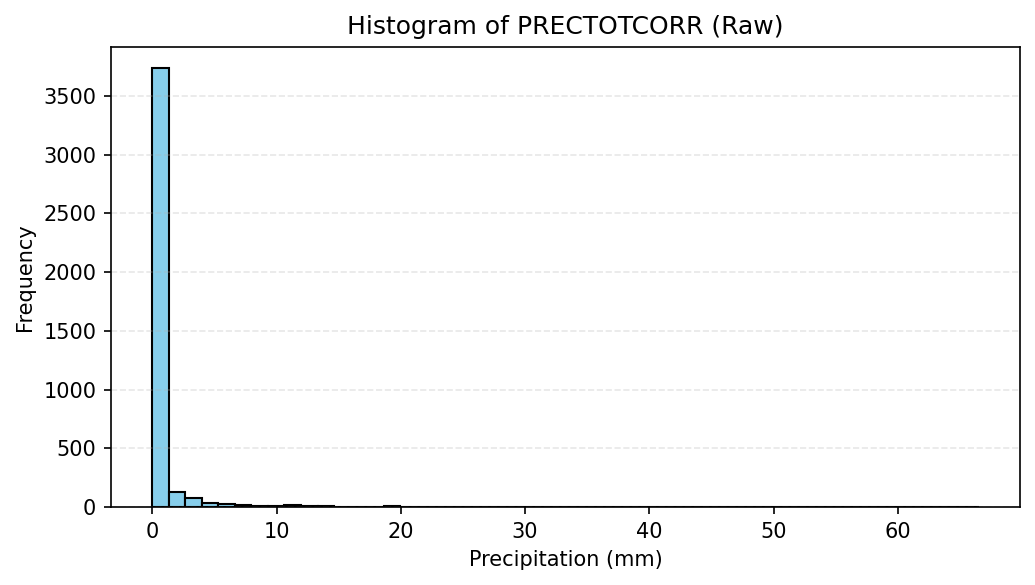

In [107]:
plt.figure(figsize=(7,4), dpi=150)

plt.hist(df["PRECTOTCORR"], bins=50, color="skyblue", edgecolor="black")

plt.title("Histogram of PRECTOTCORR (Raw)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Log-Transformed Histogram

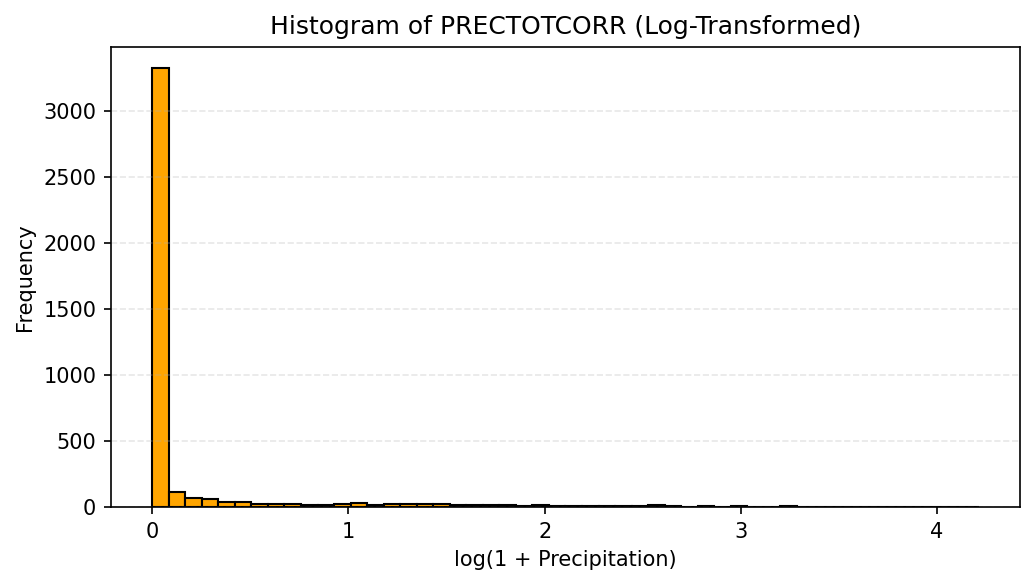

In [108]:
df["PRECTOTCORR_log"] = np.log1p(df["PRECTOTCORR"])

plt.figure(figsize=(7,4), dpi=150)

plt.hist(df["PRECTOTCORR_log"], bins=50, color="orange", edgecolor="black")

plt.title("Histogram of PRECTOTCORR (Log-Transformed)")
plt.xlabel("log(1 + Precipitation)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Distribution Analysis of PRECTOTCORR

The rainfall variable (PRECTOTCORR) shows a **very strong right-skewed distribution**, with an overwhelming concentration of observations near zero:

- Most observations are clustered at **zero or near-zero precipitation**, indicating that dry days dominate the dataset.
- A relatively small number of **high-intensity rainfall events** create a long right tail, with precipitation extending to very large values.
- This confirms rainfall is **intermittent and highly unevenly distributed**, occurring in bursts rather than consistently through time.

After applying a logarithmic transformation:

- The distribution becomes **less compressed and easier to interpret**, especially among low and moderate rainfall amounts.
- Extreme precipitation events are compressed, reducing their dominance while preserving their presence.
- The transformed histogram reveals more structure in rainfall variability that is largely hidden in the raw distribution.

### 📌 Conclusion

- The original rainfall distribution is **highly skewed and strongly non-normal**, with substantial zero inflation.
- A **log transformation is appropriate** for modeling, correlation analysis, and improved visualization.
- Rainfall variability appears driven by **rare but intense storm events**, while most days remain dry or receive minimal rainfall.
- This pattern supports earlier findings that **precipitation is episodic and represents a major source of climate variability** in the dataset.

### Bubble Chart: T2M vs RH2M (size = PRECTOTCORR)

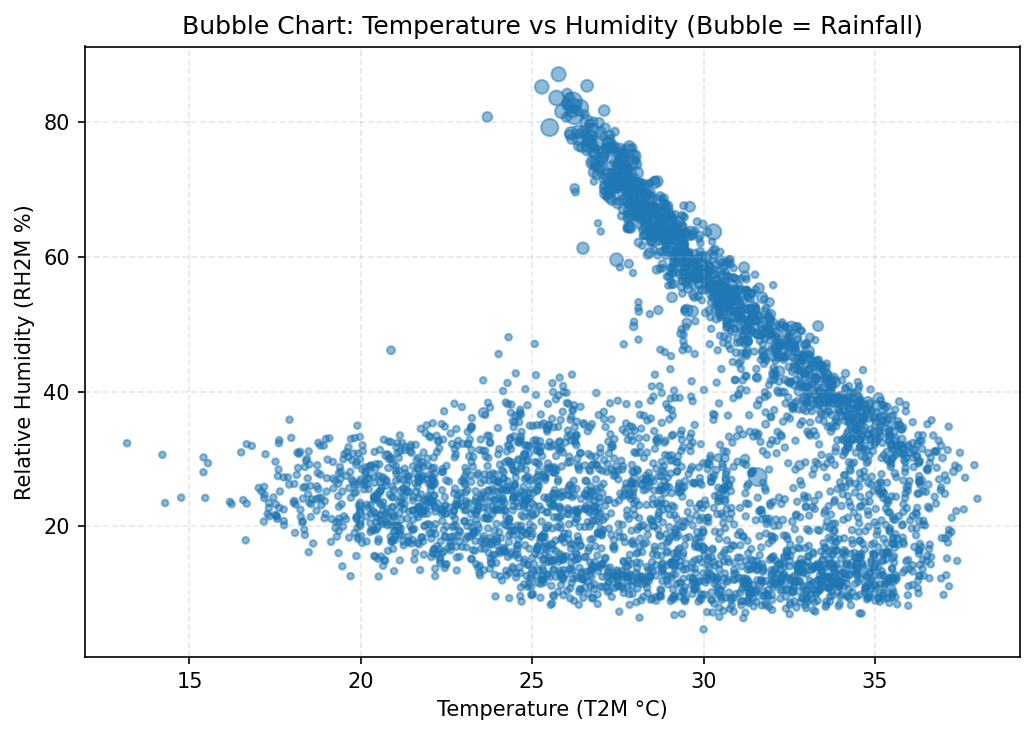

In [109]:
plt.figure(figsize=(7,5), dpi=150)

# Scale bubble size (important: rainfall can be highly skewed)
sizes = np.sqrt(df["PRECTOTCORR"] + 1) * 10  # sqrt reduces extreme dominance

plt.scatter(
    df["T2M"],          # X-axis: Temperature
    df["RH2M"],         # Y-axis: Humidity
    s=sizes,            # Bubble size: Rainfall
    alpha=0.5
)

plt.title("Bubble Chart: Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M °C)")
plt.ylabel("Relative Humidity (RH2M %)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Bubble Chart Analysis: Temperature, Humidity and Rainfall

The bubble chart highlights a strong interaction between **temperature, humidity, and precipitation**, while also reinforcing patterns observed in the earlier scatter plots.

- A pronounced **negative relationship** is visible between temperature and relative humidity — as temperatures rise, humidity generally declines, indicating strong temperature–moisture coupling.

- Larger bubbles (higher rainfall amounts) are concentrated mainly in **higher humidity conditions (roughly 60–85%)** and **moderate temperatures (around 26–31°C)**, suggesting rainfall events occur when atmospheric moisture is elevated.

- Warmer and drier conditions (high temperature, low humidity) are dominated by **smaller bubbles**, indicating low precipitation or dry-day conditions.

- The clustering pattern shows precipitation is not randomly distributed, but occurs within distinct **temperature–humidity regimes**, particularly where moisture availability is high.

- Bubble sizes are generally sparse across very hot and dry conditions, reinforcing that rainfall is more strongly linked to humidity than to temperature alone.

### 📌 Conclusion

- Rainfall is strongly associated with **humid atmospheric conditions**, with larger precipitation events concentrated in moist air masses.
- Wetter days tend to occur under **moderate-to-warm temperatures**, rather than the hottest and driest conditions.
- **Humidity appears to be a stronger driver of precipitation variability than temperature alone.**
- The chart reinforces earlier findings that **moisture dynamics, rather than temperature extremes, are a major driver of climate variability** in the dataset.